In [39]:
from copy import deepcopy
from pathlib import Path
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from open3d.web_visualizer import draw
from scipy.spatial.transform import Rotation as R
from tqdm import tqdm

In [ ]:
def pose_to_transformation_matrix(pose):
    """Convert a pose (px, py, pz, qx, qy, qz, qw) to a 4x4 transformation matrix."""
    translation = pose[:3]
    rotation = R.from_quat(pose[3:]).as_matrix()
    transformation = np.eye(4)
    transformation[:3, :3] = rotation
    transformation[:3, 3] = translation
    return transformation


def relative_position_diff(pose1, pose2):
    """Calculate the relative position difference between two poses."""
    pos1 = pose1[:3]
    pos2 = pose2[:3]
    return np.linalg.norm(pos2 - pos1)


def relative_rotation_diff(pose1, pose2):
    """Calculate the relative rotation difference between two poses."""
    quat1 = pose1[3:]
    quat2 = pose2[3:]
    return R.from_quat(quat1).inv() * R.from_quat(quat2)


# Multimodal Place Recognition - Exploratory Data Analysis

This notebook explores the dataset structure and performs interactive 3D visualization of voxelized metric maps using Open3D's web visualizer for Jupyter.


##  Data directory structure

In [2]:
_repo_name = "multimodal-place-recognition"
# iterate over current directory and its parents to find the repository root
_current_path = Path.cwd().resolve()
for p in [_current_path, *_current_path.parents]:
    if (p / ".git").is_dir() or p.name == _repo_name:
        REPO_ROOT = p
        break
else:
    raise FileNotFoundError(f"Repository root for '{_repo_name}' not found")
print(f"Repository root for '{_repo_name}' found at: {REPO_ROOT}")

Repository root for 'multimodal-place-recognition' found at: /home/melekhin_aa/Work/SberRobotics/multimodal-place-recognition


### Dataset: `2025-02-27_10-19`

Explore the data directory structure and validate the dataset integrity.

In [3]:
data_dir = REPO_ROOT / "data" / "2025-02-27_10-19"

if not data_dir.exists():
    raise FileNotFoundError(f"Data directory '{data_dir}' does not exist")

if data_dir.is_symlink():
    target_path = data_dir.readlink()
    resolved_path = data_dir.resolve()
    print(f"📁 Data directory: {data_dir}")
    print(f"🔗 Symbolic link target: {target_path}")
    print(f"📍 Resolved absolute path: {resolved_path}")

    if not resolved_path.exists():
        raise FileNotFoundError(f"Symbolic link target '{resolved_path}' does not exist")
    print("✅ Symbolic link is valid and target exists")
else:
    print(f"📁 Data directory (regular): {data_dir}")

print(f"📊 Using data from: {data_dir.resolve()}")


📁 Data directory: /home/melekhin_aa/Work/SberRobotics/multimodal-place-recognition/data/2025-02-27_10-19
🔗 Symbolic link target: /home/melekhin_aa/Datasets/SberRobotics/2025-02-27_10-19
📍 Resolved absolute path: /home/melekhin_aa/Datasets/SberRobotics/2025-02-27_10-19
✅ Symbolic link is valid and target exists
📊 Using data from: /home/melekhin_aa/Datasets/SberRobotics/2025-02-27_10-19


In [4]:
def print_tree(path, prefix=""):
    entries = sorted(path.iterdir())
    for idx, entry in enumerate(entries):
        if idx >= 5:
            print(prefix + "...")
            break
        if entry.is_dir():
            print(f"{prefix}{entry.name}/")
            print_tree(entry, prefix + "    ")
        else:
            print(f"{prefix}{entry.name}")


print_tree(data_dir)

keyframe_map/
    poses.csv
    scans/
        000000.pcd
        000001.pcd
        000002.pcd
        000003.pcd
        000004.pcd
        ...
metric_map/
    map.pcd
    map_voxelized_0.1.pcd
    map_voxelized_0.3.pcd
    trajectory.csv


## 3D Map Analysis

Load and visualize the voxelized metric map using Open3D's Jupyter-native web visualizer. This approach provides interactive 3D visualization directly in the notebook without external dependencies.

In [5]:
map_filepath = data_dir / "metric_map" / "map_voxelized_0.3.pcd"
assert map_filepath.exists(), f"Metric map file '{map_filepath}' does not exist"


In [6]:
# Load the point cloud from the PCD file
print(f"Loading point cloud from: {map_filepath}")
pcd = o3d.io.read_point_cloud(str(map_filepath))

# Display basic information about the point cloud
print("Point cloud loaded successfully!")
print(f"Number of points: {len(pcd.points):,}")
print(f"Has colors: {pcd.has_colors()}")
print(f"Has normals: {pcd.has_normals()}")

# Get bounding box information
bbox = pcd.get_axis_aligned_bounding_box()
print("Bounding box:")
print(f"  Min: {bbox.min_bound}")
print(f"  Max: {bbox.max_bound}")
print(f"  Size: {bbox.max_bound - bbox.min_bound}")

# Basic statistics
if len(pcd.points) > 0:
    points = np.asarray(pcd.points)
    print("Point cloud statistics:")
    print(f"  X range: [{points[:, 0].min():.2f}, {points[:, 0].max():.2f}]")
    print(f"  Y range: [{points[:, 1].min():.2f}, {points[:, 1].max():.2f}]")
    print(f"  Z range: [{points[:, 2].min():.2f}, {points[:, 2].max():.2f}]")

Loading point cloud from: /home/melekhin_aa/Work/SberRobotics/multimodal-place-recognition/data/2025-02-27_10-19/metric_map/map_voxelized_0.3.pcd
Point cloud loaded successfully!
Number of points: 62,793
Has colors: True
Has normals: False
Bounding box:
  Min: [-74.6880188  -74.8709259  -74.03062439]
  Max: [53.792099   61.80364609 32.2806015 ]
  Size: [128.4801178  136.67457199 106.31122589]
Point cloud statistics:
  X range: [-74.69, 53.79]
  Y range: [-74.87, 61.80]
  Z range: [-74.03, 32.28]


In [ ]:
print("Creating Jupyter-native 3D visualization...")

print("Applying default blue color to the point cloud for better visibility")
pcd.paint_uniform_color([0.2, 0.5, 0.8])  # Nice blue color

# Estimate normals if not present (useful for better lighting in visualization)
if not pcd.has_normals():
    print("Estimating normals for better visualization...")
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.5, max_nn=30))

print("🎯 Displaying interactive WebRTC-based visualization...")
print("Features:")
print("  ✅ Embedded directly in the notebook cell")
print("  ✅ Full 3D interaction (rotate, zoom, pan)")
print("  ✅ No external windows or GLFW dependencies")
print("  ✅ WebRTC streaming for smooth performance")

# Use the proper Jupyter web visualizer - this is the official solution!
try:
    draw(
        geometry=[pcd],
        title="Voxelized Metric Map - Interactive 3D Viewer",
        width=1000,
        height=700,
        point_size=1,
        show_ui=True,
        eye=np.array([10, 10, 40]),  # Camera position
        lookat=np.array([10, 10, 0]),  # Look at origin
        bg_color=(1.0, 1.0, 1.0, 1.0),
        up=[0, 0, 1],
    )
except Exception as e:
    print(f"⚠️  WebRTC visualization failed: {e}")
    print("💡 Fallback: This might indicate WebRTC is not available.")
    print("   The point cloud was still loaded successfully for analysis!")
    print(f"   Point cloud info: {len(pcd.points):,} points")

    # Alternative: Show basic statistics as fallback
    if len(pcd.points) > 0:
        points_array = np.asarray(pcd.points)
        print(f"   Spatial extent: {points_array.max(axis=0) - points_array.min(axis=0)}")
        print("   Consider using the statistical analysis below for insights.")

### Statistical Analysis

Analyze point cloud distribution and generate 2D visualizations to understand the spatial characteristics of the metric map.

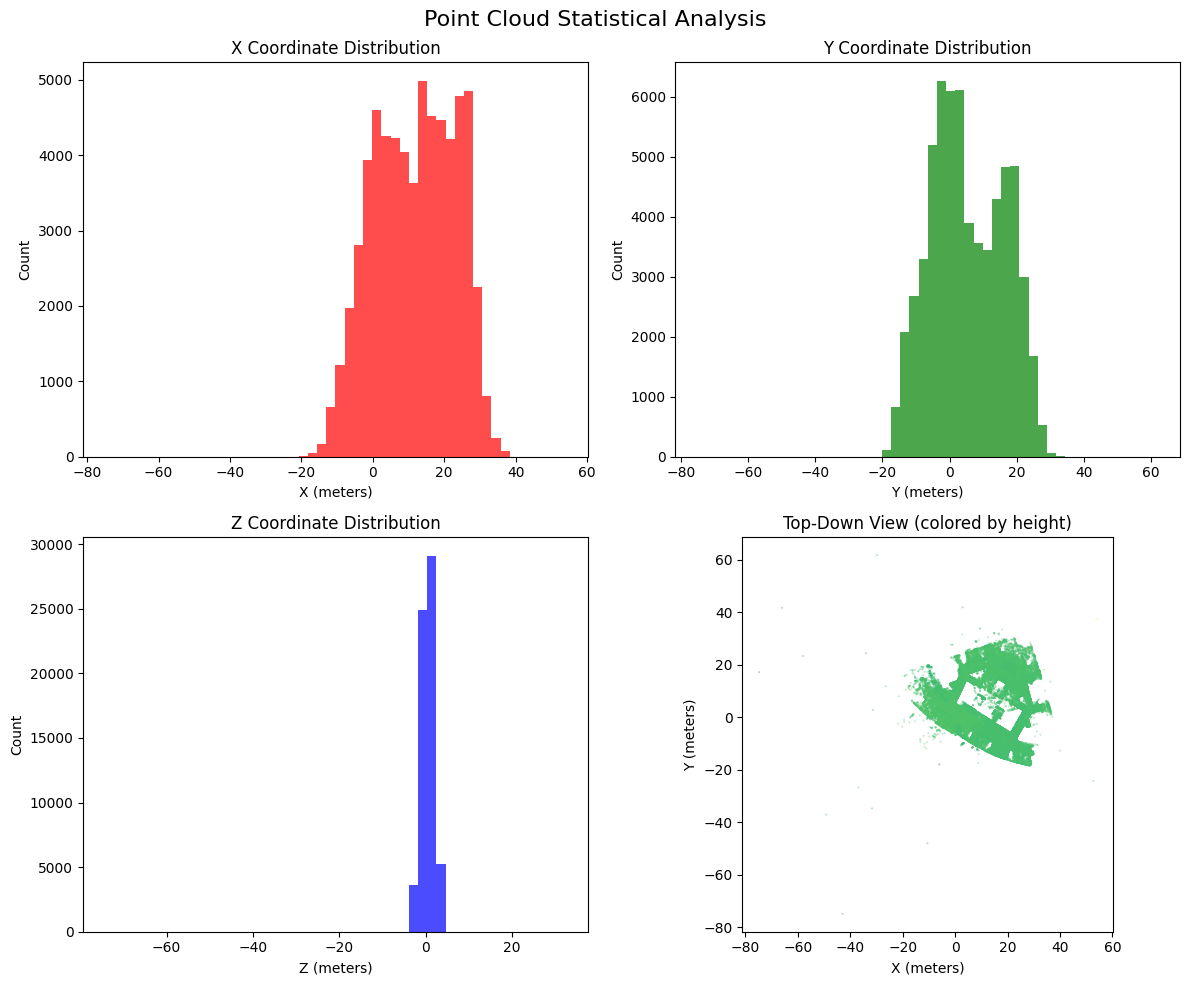

Point cloud density: 0.03 points/m³
Total volume: 1866821.42 m³


In [8]:
# Additional point cloud analysis and visualizations

# 1. Statistical analysis of point distribution
points = np.asarray(pcd.points)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Point Cloud Statistical Analysis", fontsize=16)

# Histogram of X coordinates
axes[0, 0].hist(points[:, 0], bins=50, alpha=0.7, color="red")
axes[0, 0].set_title("X Coordinate Distribution")
axes[0, 0].set_xlabel("X (meters)")
axes[0, 0].set_ylabel("Count")

# Histogram of Y coordinates
axes[0, 1].hist(points[:, 1], bins=50, alpha=0.7, color="green")
axes[0, 1].set_title("Y Coordinate Distribution")
axes[0, 1].set_xlabel("Y (meters)")
axes[0, 1].set_ylabel("Count")

# Histogram of Z coordinates
axes[1, 0].hist(points[:, 2], bins=50, alpha=0.7, color="blue")
axes[1, 0].set_title("Z Coordinate Distribution")
axes[1, 0].set_xlabel("Z (meters)")
axes[1, 0].set_ylabel("Count")

# 2D projection (top-down view)
axes[1, 1].scatter(points[:, 0], points[:, 1], s=0.1, alpha=0.5, c=points[:, 2], cmap="viridis")
axes[1, 1].set_title("Top-Down View (colored by height)")
axes[1, 1].set_xlabel("X (meters)")
axes[1, 1].set_ylabel("Y (meters)")
axes[1, 1].set_aspect("equal")

plt.tight_layout()
plt.show()

# Print density information
volume = np.prod(bbox.max_bound - bbox.min_bound)
density = len(pcd.points) / volume
print(f"Point cloud density: {density:.2f} points/m³")
print(f"Total volume: {volume:.2f} m³")

## Keyframes analysis


### Draw map with keyframes

Visualize robot trajectory as coordinate frames overlaid on the 3D map.

In [ ]:
keyframes_dir = data_dir / "keyframe_map"
assert keyframes_dir.exists(), f"Keyframes directory '{keyframes_dir}' does not exist"

poses_df = pd.read_csv(keyframes_dir / "poses.csv")
assert not poses_df.empty, "Keyframes poses DataFrame is empty"
print(f"Keyframes poses DataFrame loaded with {len(poses_df)} entries")
# Display the first few rows of the poses DataFrame
print("Keyframes poses DataFrame preview:")
print(poses_df.head())
# Visualize keyframes in the point cloud
keyframes_positions = poses_df[["px", "py", "pz"]].values
keyframes_quats = poses_df[["qx", "qy", "qz", "qw"]].values

coordinate_frames = []
frame_size = 0.5  # Size of the coordinate axes in meters

for i, (pos, quat) in enumerate(zip(keyframes_positions, keyframes_quats)):
    # Create a coordinate frame (RGB axes: X=Red, Y=Green, Z=Blue)
    frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=frame_size)

    # Note: Open3D expects [x, y, z, w] format
    rotation_matrix = R.from_quat(quat).as_matrix()

    # Create transformation matrix (4x4)
    transformation = np.eye(4)
    transformation[:3, :3] = rotation_matrix  # Set rotation part
    transformation[:3, 3] = pos  # Set translation part

    # Apply transformation to the coordinate frame
    frame.transform(transformation)
    coordinate_frames.append(frame)

try:
    draw(
        geometry=[pcd, *coordinate_frames],
        title="Voxelized Metric Map with Keyframes - Interactive 3D Viewer",
        width=1000,
        height=700,
        point_size=1,
        show_ui=True,
        eye=np.array([10, 10, 40]),  # Camera position
        lookat=np.array([10, 10, 0]),  # Look at origin
        up=[0, 0, 1],  # Z-axis up
    )
except Exception as e:
    print(f"⚠️  WebRTC visualization with keyframes failed: {e}")

### Keyframes statistics

Load individual LiDAR scans and analyze point cloud characteristics.

### Collect stats about keyframes

In [40]:
scans_dir = keyframes_dir / "scans"
assert scans_dir.exists(), f"Scans directory '{scans_dir}' does not exist"
print(f"📂 Scans directory: {scans_dir}")

scans_filepaths = sorted([f for f in scans_dir.glob("*.pcd") if f.is_file()])
if not scans_filepaths:
    raise FileNotFoundError(f"No PCD files found in scans directory '{scans_dir}'")
print(f"Found {len(scans_filepaths)} scans in the directory:")

number_of_points = []
scans_pcds = []
for filepath in tqdm(scans_filepaths, desc="Loading scans", leave=False):
    scan_pcd = o3d.io.read_point_cloud(str(filepath))
    scans_pcds.append(scan_pcd)
    number_of_points.append(len(scan_pcd.points))

# Display statistics about the scans
print("📊 Statistics about scans:")
print(f"  Total scans: {len(scans_filepaths)}")
print(f"  Total points across all scans: {sum(number_of_points):,}")
print(f"  Mean points per scan: {np.mean(number_of_points):.2f}")
print(f"  Stddev points per scan: {np.std(number_of_points):.2f}")
print(f"  Min points in a single scan: {np.min(number_of_points):,}")
print(f"  Max points in a single scan: {np.max(number_of_points):,}")
print(f"  Median points in a single scan: {np.median(number_of_points):,}")

📂 Scans directory: /home/melekhin_aa/Work/SberRobotics/multimodal-place-recognition/data/2025-02-27_10-19/keyframe_map/scans
Found 1360 scans in the directory:


Loading scans:  25%|██▍       | 335/1360 [00:00<00:00, 3341.78it/s]

📊 Statistics about scans:
  Total scans: 1360
  Total points across all scans: 3,780,370
  Mean points per scan: 2779.68
  Stddev points per scan: 300.07
  Min points in a single scan: 1,878
  Max points in a single scan: 3,090
  Median points in a single scan: 2,881.5


### Visualize single scan

### Single scan visualization

Inspect individual LiDAR scan in sensor coordinate frame.

In [ ]:
# visualize single scan
scan_id = 10
try:
    single_scan = scans_pcds[scan_id]
    draw(
        geometry=[single_scan],
        title="Single Scan Point Cloud",
        width=800,
        height=600,
        point_size=2,
        show_ui=True,
        eye=np.array([0, 0, 20]),
        lookat=np.array([0, 0, 0]),
        up=[0, 0, 1],
    )
except Exception as e:
    print(f"⚠️  WebRTC visualization of single scan failed: {e}")


### Merge and visualize set of consecutive scans

### Local map reconstruction

Transform and merge consecutive scans to create local map segments.

In [ ]:
scans_id_from, scans_id_to = 300, 350  # excluding the last one

# collect scans in the range
scans_to_merge = scans_pcds[scans_id_from:scans_id_to]
# their poses
scans_poses = poses_df.iloc[scans_id_from:scans_id_to][["px", "py", "pz", "qx", "qy", "qz", "qw"]].values
scans_transforms = [pose_to_transformation_matrix(pose) for pose in scans_poses]

# Merge scans
coordinate_frames = []
frame_size = 0.5  # Size of the coordinate axes in meters
merged_scan = o3d.geometry.PointCloud()
for scan, transform in zip(scans_to_merge, scans_transforms):
    # Create a coordinate frame for the current scan
    frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=frame_size)
    frame.transform(transform)
    coordinate_frames.append(frame)

    # Transform and merge the scan
    transformed_scan = deepcopy(scan).transform(transform)
    merged_scan += transformed_scan

scan_center_point = np.mean(np.asarray(merged_scan.points), axis=0)

# Visualize the merged scan
try:
    draw(
        geometry=[merged_scan, *coordinate_frames],
        title=f"Merged Scan from {scans_id_from} to {scans_id_to}",
        width=1000,
        height=700,
        point_size=2,
        show_ui=True,
        eye=scan_center_point + np.array([0, 0, 20]),  # Camera position
        lookat=scan_center_point,  # Look at origin
        up=[0, 0, 1],  # Z-axis up
    )
except Exception as e:
    print(f"⚠️  WebRTC visualization of merged scan failed: {e}")

# Collect statistics about the merged scan
merged_points = np.asarray(merged_scan.points)
print("📊 Statistics about the merged scan:")
print(f"  Total points: {len(merged_points):,}")

### Trajectory analysis

Analyze relative motion between consecutive robot poses.

In [54]:
# Calculate relative differences for all consecutive poses
relative_diffs = []
for i in range(len(scans_poses) - 1):
    pos_diff = relative_position_diff(scans_poses[i], scans_poses[i + 1])
    rot_diff = relative_rotation_diff(scans_poses[i], scans_poses[i + 1])
    relative_diffs.append((pos_diff, rot_diff.magnitude()))
# Convert to DataFrame for easier analysis
relative_diffs_df = pd.DataFrame(relative_diffs, columns=["position_diff", "rotation_diff"])
# Display basic statistics about the relative differences
print("📊 Statistics about relative differences between consecutive poses:\n")
print(f"  Total pairs: {len(relative_diffs_df)}\n")
print(f"  Mean position diff:\t{relative_diffs_df['position_diff'].mean():.2f} m")
print(f"  Stddev position diff:\t{relative_diffs_df['position_diff'].std():.2f} m")
print(f"  Min position diff:\t{relative_diffs_df['position_diff'].min():.2f} m")
print(f"  Max position diff:\t{relative_diffs_df['position_diff'].max():.2f} m")
print(f"  Median position diff:\t{relative_diffs_df['position_diff'].median():.2f} m")
print()
print(
    f"  Mean rotation diff:\t{relative_diffs_df['rotation_diff'].mean():.2f} rad",
    f"(≈ {np.degrees(relative_diffs_df['rotation_diff'].mean()):.2f}°)",
)
print(
    f"  Stddev rotation diff:\t{relative_diffs_df['rotation_diff'].std():.2f} rad",
    f"(≈ {np.degrees(relative_diffs_df['rotation_diff'].std()):.2f}°)",
)
print(
    f"  Min rotation diff:\t{relative_diffs_df['rotation_diff'].min():.2f} rad",
    f"(≈ {np.degrees(relative_diffs_df['rotation_diff'].min()):.2f}°)",
)
print(
    f"  Max rotation diff:\t{relative_diffs_df['rotation_diff'].max():.2f} rad",
    f"(≈ {np.degrees(relative_diffs_df['rotation_diff'].max()):.2f}°)",
)
print(
    f"  Median rotation diff:\t{relative_diffs_df['rotation_diff'].median():.2f} rad",
    f"(≈ {np.degrees(relative_diffs_df['rotation_diff'].median()):.2f}°)",
)

📊 Statistics about relative differences between consecutive poses:

  Total pairs: 49

  Mean position diff:	0.13 m
  Stddev position diff:	0.01 m
  Min position diff:	0.12 m
  Max position diff:	0.14 m
  Median position diff:	0.13 m

  Mean rotation diff:	0.02 rad (≈ 0.88°)
  Stddev rotation diff:	0.01 rad (≈ 0.41°)
  Min rotation diff:	0.00 rad (≈ 0.15°)
  Max rotation diff:	0.04 rad (≈ 2.06°)
  Median rotation diff:	0.01 rad (≈ 0.81°)
